# Дополнительные задания 4–5

Влияние миграции и закрытие города при доле инфицированных выше 10%.

## Окружение

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("experiments.jl"))

comprehensive_analysis (generic function with 2 methods)

## Задание 4: анализ базовой серии

In [2]:
baseline =
    CSV.read(datafile("sir_migration_effect", "summary.csv"), DataFrame)
minimum_time = minimum(baseline.peak_time)
fastest = baseline[baseline.peak_time .== minimum_time, :]
CSV.write(datafile("sir_extra_4_5", "fastest_migration.csv"), fastest)
display(fastest)

Row,intensity,peak_time,peak
,Float64,Float64,Float64
1,0.0,15.0,0.333259


## Задание 5: карантин и парное сравнение по seed

In [3]:
quarantine = migration_scan("sir_extra_4_5/quarantine"; threshold = 0.1)
plain = CSV.read(
    datafile("sir_migration_effect", "migration_scan_all.csv"),
    DataFrame,
)
paired = innerjoin(
    select(
        plain,
        :intensity,
        :seed,
        :peak=>:peak_without,
        :peak_time=>:time_without,
    ),
    select(
        quarantine.df,
        :intensity,
        :seed,
        :peak=>:peak_with,
        :peak_time=>:time_with,
    );
    on = [:intensity, :seed],
)
paired.peak_reduction = paired.peak_without .- paired.peak_with
paired.time_delay = paired.time_with .- paired.time_without
CSV.write(datafile("sir_extra_4_5", "paired_results.csv"), paired)
summary = combine(
    groupby(paired, :intensity),
    :peak_reduction=>mean=>:peak_reduction,
    :time_delay=>mean=>:time_delay,
)
CSV.write(datafile("sir_extra_4_5", "summary.csv"), summary)

"/workspace/labs/lab04/project/data/sir_extra_4_5/summary.csv"

## Результаты карантина

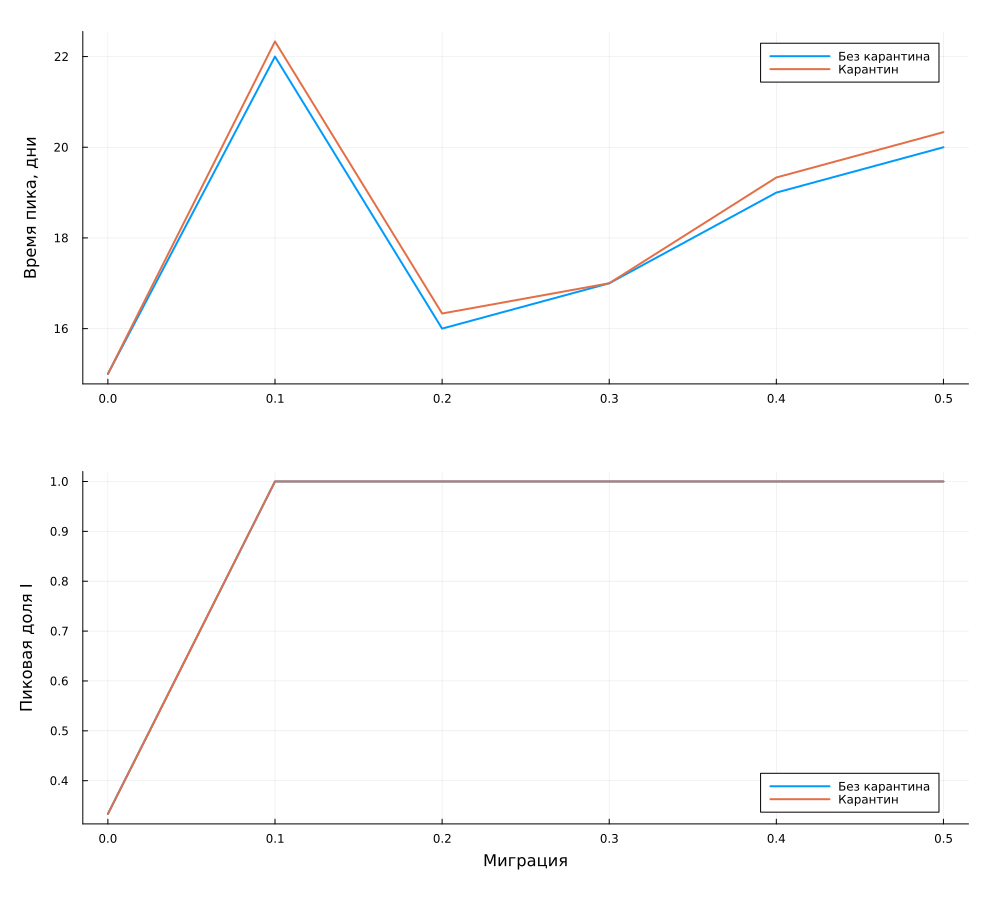

Row,intensity,peak_reduction,time_delay
,Float64,Float64,Float64
1,0.0,0.0,0.0
2,0.1,0.0,0.333333
3,0.2,0.0,0.333333
4,0.3,0.0,0.0
5,0.4,0.0,0.333333
6,0.5,0.0,0.333333


In [4]:
p1 = plot(
    baseline.intensity,
    baseline.peak_time;
    label = "Без карантина",
    ylabel = "Время пика, дни",
)
plot!(
    p1,
    quarantine.grouped.intensity,
    quarantine.grouped.peak_time;
    label = "Карантин",
)
p2 = plot(
    baseline.intensity,
    baseline.peak;
    label = "Без карантина",
    ylabel = "Пиковая доля I",
    xlabel = "Миграция",
)
plot!(
    p2,
    quarantine.grouped.intensity,
    quarantine.grouped.peak;
    label = "Карантин",
)
figure = plot(p1, p2; layout = (2, 1), size = (1000, 900))
savefig(figure, imagefile("13-plot.png"))
display(figure)
summary

Закрытие города запрещает исходящие перемещения; диагональ строки матрицы
становится единицей. Остальные строки не меняются, входящий поток возможен.